In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/naimdotcom/Machine-Learning/main/data/housing.csv")

In [3]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].mean())

In [8]:
import matplotlib.pyplot as plt


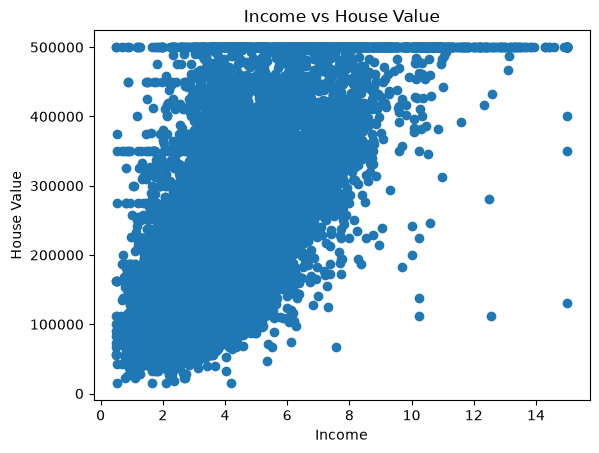

In [9]:
plt.scatter(data['median_income'], data['median_house_value'])
plt.xlabel("Income")
plt.ylabel("House Value")
plt.title("Income vs House Value")
plt.show()

In [10]:
x = data['median_income'].values
y= data['median_house_value'].values

In [11]:
print(x.shape,y.shape)

(20640,) (20640,)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=42)


In [ ]:
# 1. Calculate stats ONLY from the training set
x_train_mean = np.mean(X_train)
x_train_std = np.std(X_train)
y_train_mean = np.mean(y_train)
y_train_std = np.std(y_train)

# 2. Normalize the training set using training stats
x_train_norm = (X_train - x_train_mean) / x_train_std
y_train_norm = (y_train - y_train_mean) / y_train_std
print("Train Norm:", x_train_norm, y_train_norm)

# 3. Normalize the test set USING TRAINING STATS (Fix applied here)
x_test_norm = (X_test - x_train_mean) / x_train_std
y_test_norm = (y_test - y_train_mean) / y_train_std
print("Test Norm:", x_test_norm, y_test_norm)


Train Norm: [-1.52169954  0.18205382 -0.17232772 ... -0.49518065  0.96816708
 -0.68377427] [-0.73904434  1.36115317 -0.0092192  ...  0.13379879  0.66599906
  1.02571098]
Test Norm: [-1.15370815 -0.70700034 -0.20842797 ... -0.02167353  0.27275111
 -0.59570436] [-1.37785803 -1.39432677  2.54257711 ... -0.86386004 -0.6584342
  0.87055813]


In [14]:
def compute_cost(x,y, w, b):
  m = x.shape[0]
  f_wb = w*x + b
  cost = (f_wb-y)**2
  t_cost = np.sum(cost)/(2*m)
  return t_cost

In [15]:
def compute_gradient(x,y,w,b):
  f_wb = w*x + b
  m = x.shape[0]
  dj_w = np.sum((f_wb - y)*x)/m
  dj_b = np.sum(f_wb - y)/m
  return dj_w, dj_b

In [16]:
def gradient_descent(x,y,alp=0.01, iterations=1000):
  w,b=0,0
  cost_history = []
  for i in range(iterations):
    dj_w, dj_b = compute_gradient(x,y,w,b)
    w = w - alp*dj_w
    b = b - alp*dj_b
    cost = compute_cost(x,y,w,b)
    cost_history.append(cost)
  return w,b,cost_history

In [17]:
w_final, b_final, cost_history = gradient_descent(x_train_norm, y_train_norm)
print(w_final, b_final)
print(cost_history[0], cost_history[-1])
print(cost_history[-1] - cost_history[-10])

0.6883386387724578 -1.9435486550264484e-16
0.49528518260750104 0.26307450333107535
-8.756473324211811e-11


In [18]:
train_cost = compute_cost(x_train_norm, y_train_norm, w_final, b_final)
test_cost = compute_cost(x_test_norm, y_test_norm, w_final, b_final)
print(train_cost, test_cost)

0.26307450333107535 0.2640242828131802


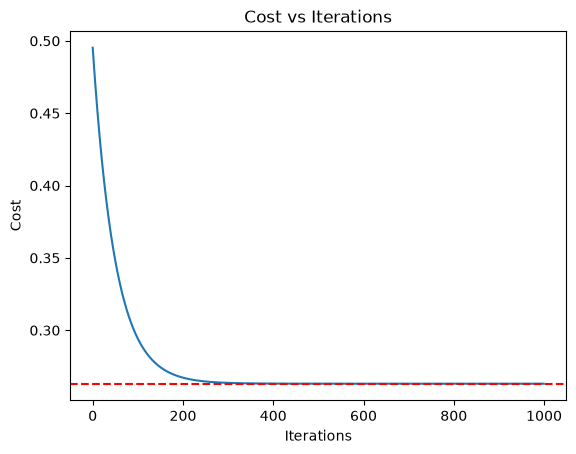

In [19]:
plt.plot(cost_history)
plt.axhline(y=cost_history[-1], color='red', linestyle='--', label=f'Final cost: {cost_history[-1]:.4f}')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.show()

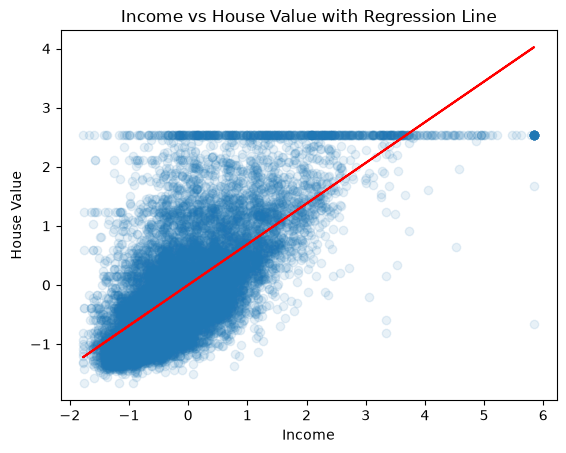

In [20]:
plt.scatter(x_train_norm, y_train_norm, alpha=0.1)
plt.plot(x_train_norm, w_final*x_train_norm + b_final, color='red')
plt.xlabel("Income")
plt.ylabel("House Value")
plt.title("Income vs House Value with Regression Line")
plt.show()

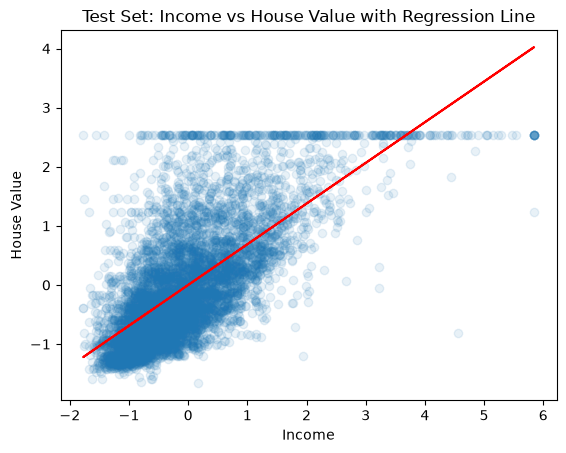

In [21]:
plt.scatter(x_test_norm, y_test_norm, alpha=0.1)
plt.plot(x_test_norm, w_final*x_test_norm + b_final, color='red')
plt.xlabel("Income")
plt.ylabel("House Value")
plt.title("Test Set: Income vs House Value with Regression Line")
plt.show()

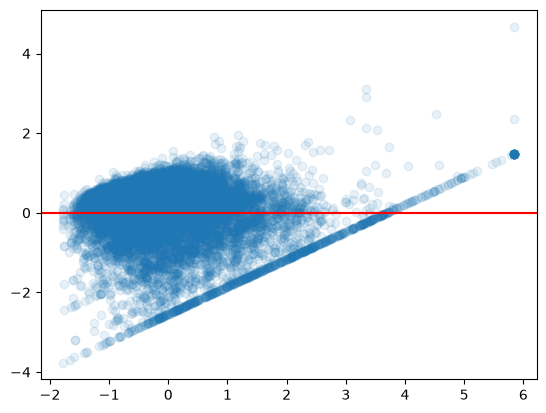

In [22]:
residuals = (w_final * x_train_norm + b_final) - y_train_norm
plt.scatter(x_train_norm, residuals, alpha=0.1)
plt.axhline(y=0, color='red')  # the ideal line

(array([3.000e+00, 3.000e+00, 5.000e+00, 1.000e+01, 1.000e+01, 2.100e+01,
        4.300e+01, 5.300e+01, 5.800e+01, 6.400e+01, 8.000e+01, 1.040e+02,
        1.400e+02, 1.580e+02, 1.790e+02, 2.500e+02, 3.330e+02, 4.010e+02,
        5.220e+02, 7.090e+02, 8.590e+02, 1.185e+03, 1.455e+03, 1.676e+03,
        1.767e+03, 1.566e+03, 1.151e+03, 5.870e+02, 2.450e+02, 9.200e+01,
        3.100e+01, 4.600e+01, 1.100e+01, 3.000e+00, 2.000e+00, 0.000e+00,
        3.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([-3.76400227, -3.59518988, -3.42637749, -3.2575651 , -3.08875271,
        -2.91994032, -2.75112793, -2.58231553, -2.41350314, -2.24469075,
        -2.07587836, -1.90706597, -1.73825358, -1.56944118, -1.40062879,
        -1.2318164 , -1.06300401, -0.89419162, -0.72537923, -0.55656683,
        -0.38775444, -0.21894205, -0.05012966,  0.11868273,  0.28749512,
         0.

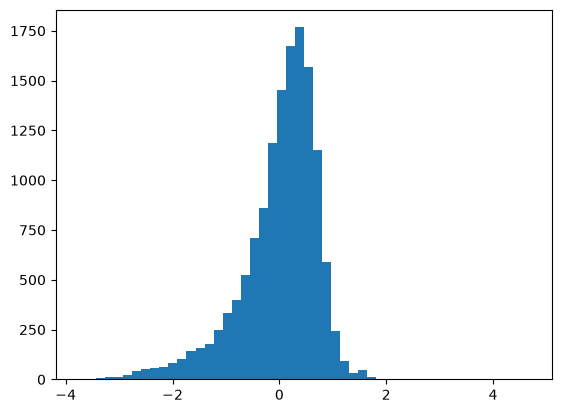

In [23]:
plt.hist(residuals, bins=50)

In [24]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train_norm.reshape(-1,1),y_train_norm)
print(model.coef_, model.intercept_)

[0.68836836] -2.0076877048217617e-16
